# Data Description

These datasets are meteorological data from the HI-SEAS weather station from four months (September through December 2016) between Mission IV and Mission V.

For each dataset, the fields are:

A row number (1-n) useful in sorting this export's results The UNIX time_t date (seconds since Jan 1, 1970). Useful in sorting this export's results with other export's results The date in yyyy-mm-dd format The local time of day in hh:mm:ss 24-hour format The numeric data, if any (may be an empty string) The text data, if any (may be an empty string)

The units of each dataset are:

Solar radiation: watts per meter^2
Temperature: degrees Fahrenheit
Humidity: percent
Barometric pressure: Hg
Wind direction: degrees
Wind speed: miles per hour
Sunrise/sunset: Hawaii time


Link: https://www.kaggle.com/datasets/dronio/SolarEnergy




# Table of Content

Importing Libraries

Loading Data

Data Wrangling

Feature Selection using Correlation Matrix

Feature Selection using SelectKBest Method

Feature Selection using Extra Tree Classifier

Feature Engineering with BoxCox, Log, Min-Max and Standard transformation

Preparing data - Standardisation and Splitting

Prediction with XGBoost

Using MultiLayer Perceptron for prediction

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest,chi2

from sklearn.model_selection import train_test_split

import xgboost as xgb

from tensorflow.keras.layers import Dense,Dropout,Activation
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.models import Sequential

from sklearn.metrics import mean_squared_error,median_absolute_error,r2_score, mean_absolute_error


import warnings 
warnings.filterwarnings("ignore")

# loading Data

In [8]:
data=pd.read_csv("SolarPrediction.csv")

In [9]:
data.head()

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB


# Data Wrangling

In [12]:
df=data.copy()

In [13]:
df["Data"]=df["Data"].apply(lambda x:x.split()[0])

In [14]:
df.Data

0        9/29/2016
1        9/29/2016
2        9/29/2016
3        9/29/2016
4        9/29/2016
           ...    
32681    12/1/2016
32682    12/1/2016
32683    12/1/2016
32684    12/1/2016
32685    12/1/2016
Name: Data, Length: 32686, dtype: object

In [15]:
df["Month"]=pd.to_datetime(df["Data"]).dt.month
df["Day"]=pd.to_datetime(df["Data"]).dt.day

df["Hour"]=pd.to_datetime(df["Time"]).dt.hour
df["Minute"]=pd.to_datetime(df["Time"]).dt.minute
df["Second"]=pd.to_datetime(df["Time"]).dt.second

In [16]:
df["risehour"]=pd.to_datetime(df["TimeSunRise"]).dt.hour
df["risemin"]=pd.to_datetime(df["TimeSunRise"]).dt.minute

df["sethour"]=pd.to_datetime(df["TimeSunSet"]).dt.hour
df["setmin"]=pd.to_datetime(df["TimeSunSet"]).dt.minute

In [17]:
df.head()

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet,Month,Day,Hour,Minute,Second,risehour,risemin,sethour,setmin
0,1475229326,9/29/2016,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00,9,29,23,55,26,6,13,18,13
1,1475229023,9/29/2016,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00,9,29,23,50,23,6,13,18,13
2,1475228726,9/29/2016,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00,9,29,23,45,26,6,13,18,13
3,1475228421,9/29/2016,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00,9,29,23,40,21,6,13,18,13
4,1475228124,9/29/2016,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00,9,29,23,35,24,6,13,18,13


In [18]:
df.drop(["UNIXTime","Data","Time","TimeSunRise","TimeSunSet"],axis=1,inplace=True)

In [19]:
df.shape

(32686, 15)

In [20]:
ip_feat=df.drop("Radiation",axis=1)
tgt=df["Radiation"]

# Feature selection using co relation matrix

<Axes: >

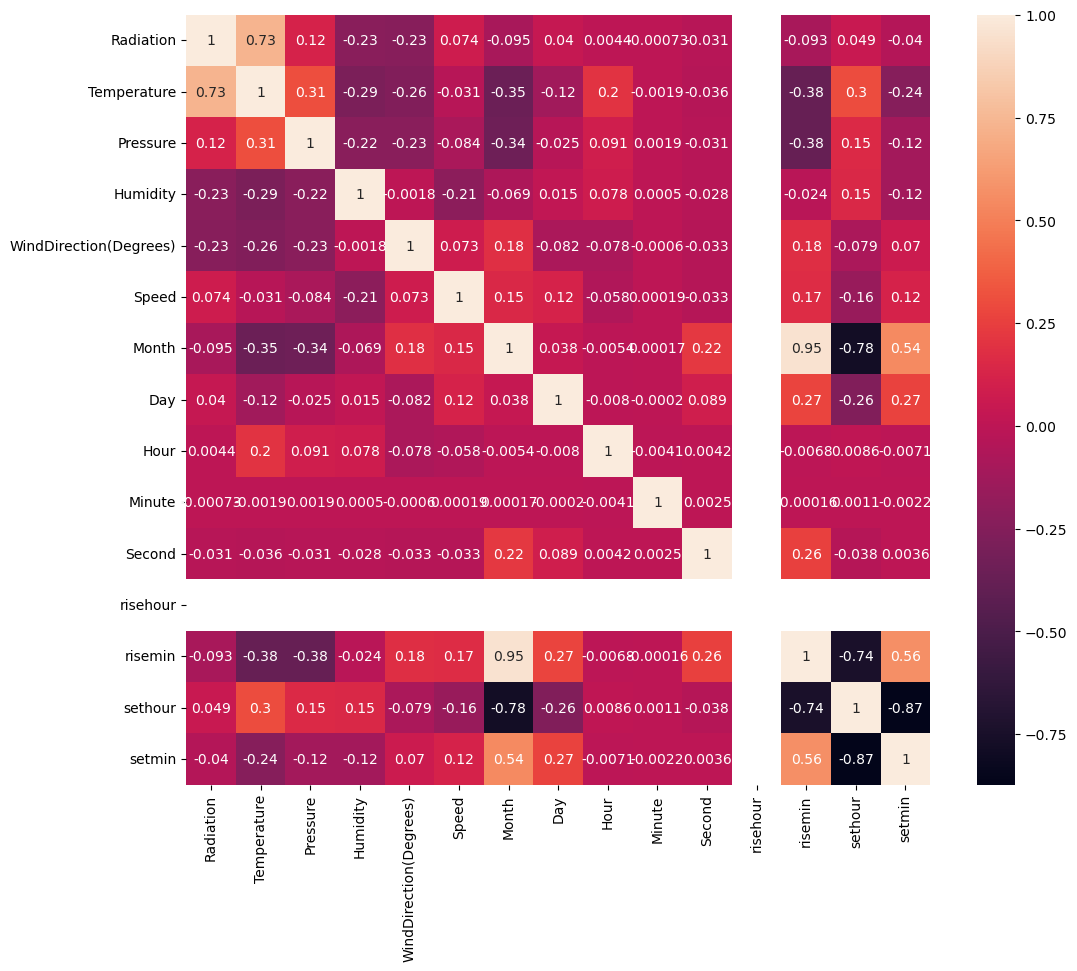

In [22]:
corr_mat=df.corr()
corr_mat

plt.figure(figsize=(12,10))
sns.heatmap(corr_mat,annot=True)

# Feature Selection using SelectKBest Method

In [24]:
bstfeat=SelectKBest(score_func=chi2,k=10)

In [25]:
label_encoder=LabelEncoder()
train_y=label_encoder.fit_transform(tgt)

In [46]:
tgt_cont = df['Radiation'].apply(lambda x : int(x*100))

In [27]:
scaled_ip_feat=MinMaxScaler().fit_transform(ip_feat)

In [28]:
fit=bstfeat.fit(scaled_ip_feat,train_y)

In [29]:
fit.scores_

array([ 1655.51616149,   527.71209526,  1600.06878743,  3294.02655388,
         771.72796028,  4721.2899351 ,  2862.20409866,   702.79493128,
        2728.50734127,  2312.41922434,            nan,  4044.45270959,
       12289.46388698,  1877.27648413])

In [30]:
score=pd.DataFrame(fit.scores_)

In [31]:
column=pd.DataFrame(ip_feat.columns)

In [32]:
feat_score=pd.concat([column,score],axis=1)
feat_score.columns=["Feature","feat_imp"]

In [33]:
feat_score.sort_values(by="feat_imp",ascending=False,inplace=True)

In [34]:
feat_score

,Feature,feat_imp
12,sethour,12289.463887
5,Month,4721.289935
11,risemin,4044.452710
3,WindDirection(Degrees),3294.026554
6,Day,2862.204099
8,Minute,2728.507341
9,Second,2312.419224
13,setmin,1877.276484
0,Temperature,1655.516161
2,Humidity,1600.068787


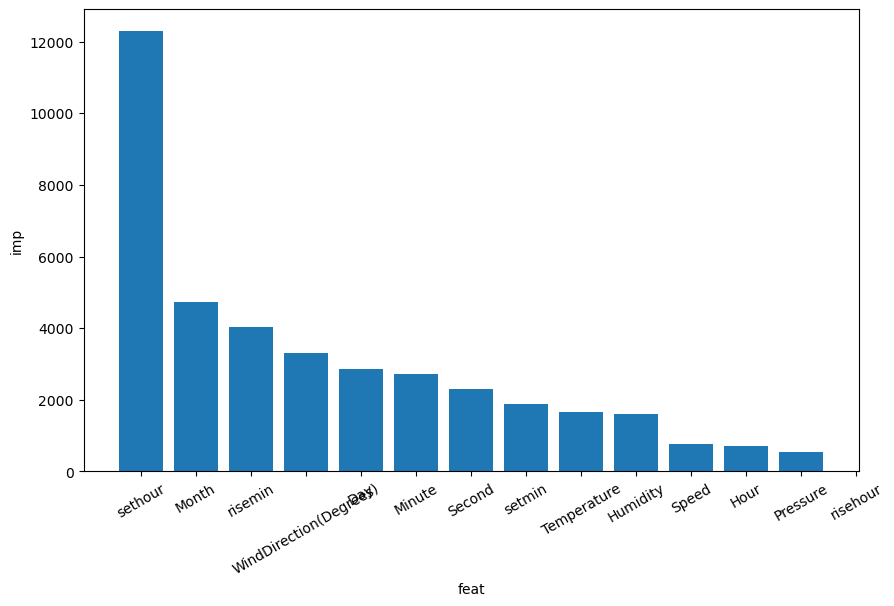

In [35]:
plt.figure(figsize=(10,6))
plt.bar(feat_score.Feature,feat_score.feat_imp)
plt.xticks(rotation=30)
plt.xlabel("feat")
plt.ylabel("imp")
plt.show()

## Feature Selection using extra Tree Classifier

In [76]:
scaled_ip_feat_sample, _, tgt_cont_sample, _ = train_test_split(
    scaled_ip_feat, tgt_cont, test_size=0.8)

In [78]:
model=ExtraTreesClassifier(n_estimators=10,max_depth=10,verbose=2)
model.fit(scaled_ip_feat_sample,tgt_cont_sample)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s


building tree 1 of 10
building tree 2 of 10
building tree 3 of 10
building tree 4 of 10
building tree 5 of 10
building tree 6 of 10
building tree 7 of 10
building tree 8 of 10
building tree 9 of 10
building tree 10 of 10


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.4s finished


ExtraTreesClassifier(max_depth=10, n_estimators=10, verbose=2)

In [80]:
feat_imp=pd.DataFrame(model.feature_importances_,index=ip_feat.columns,columns=["feat_imp"])
feat_imp.sort_values(by="feat_imp",ascending=False,inplace=True)
feat_imp

,feat_imp
Temperature,0.144605
Hour,0.115935
WindDirection(Degrees),0.097112
Humidity,0.082265
Second,0.077379
Minute,0.077336
Pressure,0.075513
setmin,0.074811
Speed,0.073789
Day,0.073427


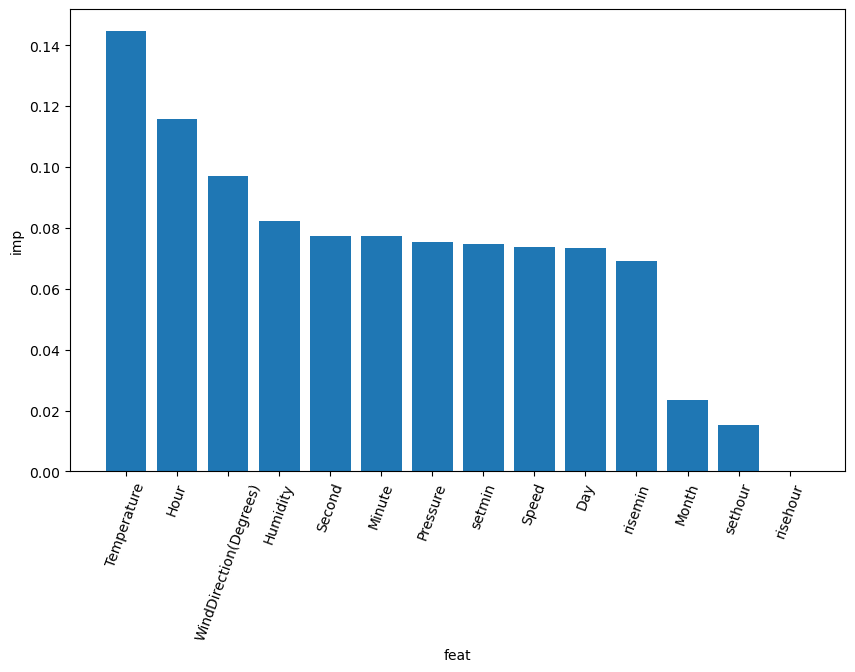

In [84]:
plt.figure(figsize=(10,6))
plt.bar(feat_imp.index,feat_imp.feat_imp)
plt.xticks(rotation=70)
plt.xlabel("feat")
plt.ylabel("imp")
plt.show()

## feat_imp with coxbox,log,min-max And Std. Transformation

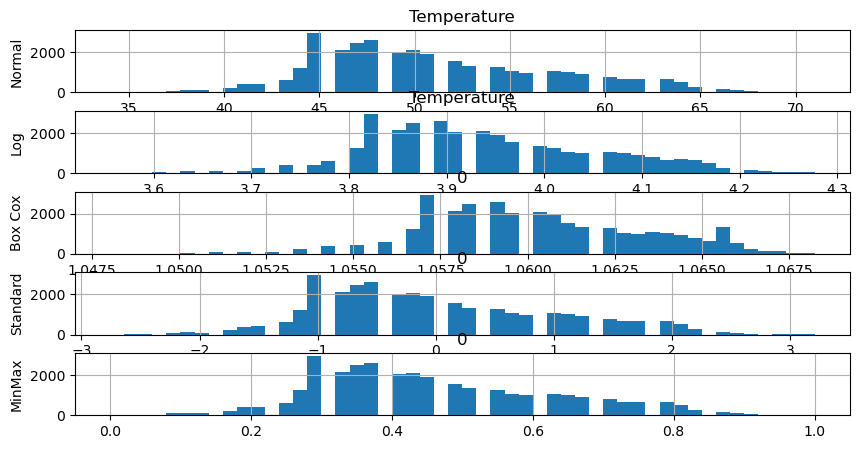

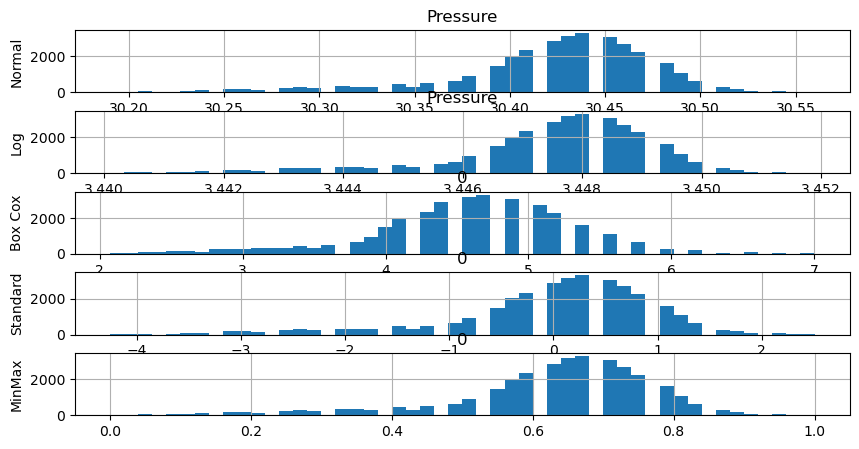

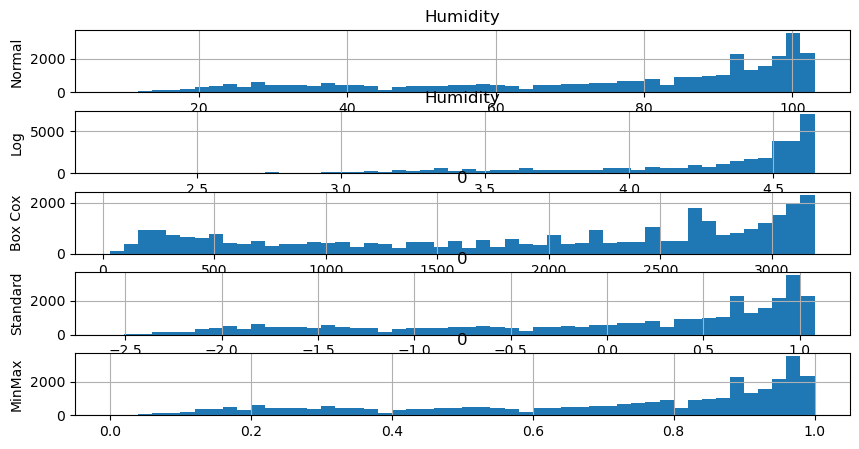

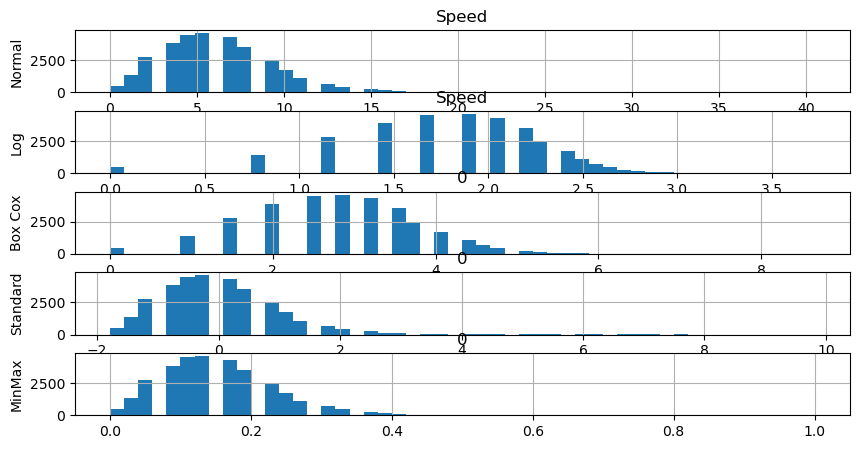

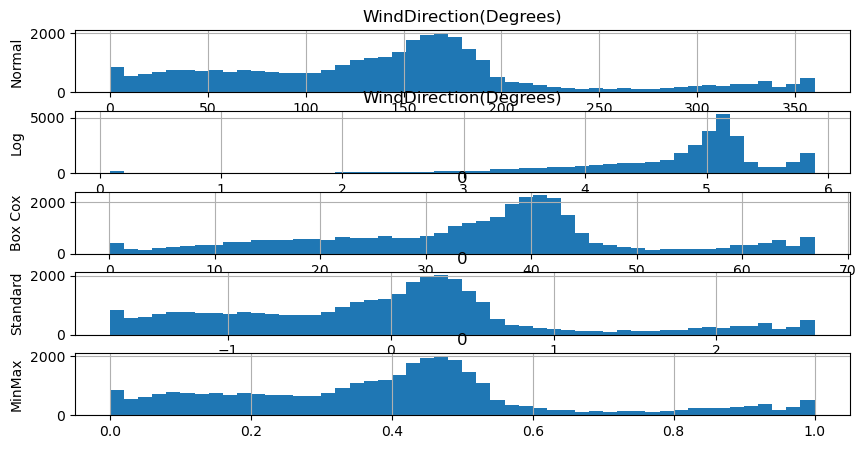

In [91]:
feat_to_transform = ['Temperature', 'Pressure', 'Humidity', 'Speed', 'WindDirection(Degrees)']

for i in feat_to_transform:
    
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 5))
    
    pd.DataFrame(ip_feat[i]).hist(ax = ax1, bins = 50)
    pd.DataFrame((ip_feat[i]+1).transform(np.log)).hist(ax = ax2, bins = 50)
    pd.DataFrame(stats.boxcox(ip_feat[i]+1)[0]).hist(ax = ax3, bins = 50)    
    pd.DataFrame(StandardScaler().fit_transform(np.array(ip_feat[i]).reshape(-1, 1))).hist(ax = ax4, bins = 50)
    pd.DataFrame(MinMaxScaler().fit_transform(np.array(ip_feat[i]).reshape(-1, 1))).hist(ax = ax5, bins = 50)
    
    ax1.set_ylabel('Normal')
    ax2.set_ylabel('Log')
    ax3.set_ylabel('Box Cox')
    ax4.set_ylabel('Standard')
    ax5.set_ylabel('MinMax')

In [95]:
transform = {'Temperature' : (ip_feat['Temperature']+1).transform(np.log), 
             'Pressure': stats.boxcox(ip_feat['Pressure']+1)[0], 
            'Humidity' : stats.boxcox(ip_feat['Humidity']+1)[0], 
            'Speed' : (ip_feat['Speed']+1).transform(np.log), 
            'WindDirection(Degrees)' : MinMaxScaler().fit_transform(
                np.array(ip_feat['WindDirection(Degrees)']).reshape(-1, 1))}

for i in transform:
    ip_feat[i] = transform[i]

In [93]:
ip_feat.head()

,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,Month,Day,Hour,Minute,Second,risehour,risemin,sethour,setmin
0,48,30.46,59,177.39,5.62,9,29,23,55,26,6,13,18,13
1,48,30.46,58,176.78,3.37,9,29,23,50,23,6,13,18,13
2,48,30.46,57,158.75,3.37,9,29,23,45,26,6,13,18,13
3,48,30.46,60,137.71,3.37,9,29,23,40,21,6,13,18,13
4,48,30.46,62,104.95,5.62,9,29,23,35,24,6,13,18,13


In [97]:
ip_feat.head()

,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,Month,Day,Hour,Minute,Second,risehour,risemin,sethour,setmin
0,3.89182,5.044903e+152,1139.358665,0.492692,1.890095,9,29,23,55,26,6,13,18,13
1,3.89182,5.044903e+152,1104.046980,0.490996,1.474763,9,29,23,50,23,6,13,18,13
2,3.89182,5.044903e+152,1069.253545,0.440894,1.474763,9,29,23,45,26,6,13,18,13
3,3.89182,5.044903e+152,1175.187489,0.382426,1.474763,9,29,23,40,21,6,13,18,13
4,3.89182,5.044903e+152,1248.392213,0.291391,1.890095,9,29,23,35,24,6,13,18,13


## Preparing Data-Standardising and splitting

In [101]:
x_train,x_test,y_train,y_test=train_test_split(ip_feat,tgt,test_size=0.2,random_state=1)
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [103]:
x_train.shape,x_test.shape

((26148, 14), (6538, 14))

## XGBoost

In [106]:
from xgboost import XGBRegressor

params={
    "learning_rate":0.1,
    "max_depth":8
}

model=XGBRegressor(**params)

In [110]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [112]:
y_pred=model.predict(x_test)

In [116]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

r2=r2_score(y_test,y_pred)

print("Performance")
print("rmse: {:.2f}".format(rmse))
print("r2: {:.2f}".format(r2))

Performance
rmse: 81.87
r2: 0.93


## using multilayer perceptron for predition

In [119]:
ip_feat.shape

(32686, 14)

In [129]:
model=None
model=Sequential()

model.add(Dense(128,activation="relu",input_dim=14))
model.add(Dropout(0,33))

model.add(Dense(64,activation="relu"))
model.add(Dropout(0,33))

model.add(Dense(32,activation="relu"))
model.add(Dropout(0,33))

model.add(Dense(1,activation="relu"))

model.compile(metrics=['mse'], loss='mae', optimizer=Adam(learning_rate=0.001))

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [133]:
history=model.fit(x_train,y_train,validation_split=0.1,epochs=50,batch_size=32)

Epoch 1/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 145.3886 - mse: 80446.9375 - val_loss: 71.2082 - val_mse: 19651.2012
Epoch 2/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 69.3655 - mse: 19218.5723 - val_loss: 62.3489 - val_mse: 15628.2598
Epoch 3/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 60.1976 - mse: 15042.1240 - val_loss: 56.5549 - val_mse: 13088.8320
Epoch 4/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 53.2625 - mse: 12529.5361 - val_loss: 50.5950 - val_mse: 11551.4678
Epoch 5/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 50.4394 - mse: 12155.4932 - val_loss: 46.9149 - val_mse: 10958.6670
Epoch 6/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 44.5942 - mse: 10140.2793 - val_loss: 45.3818 - val_mse: 10873.5078
Epoch 7/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 43.8841 - mse: 10177.4639 - val_loss: 43.8374 - val_mse: 10270.6309
Epoch 8/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 42.7906 - mse: 10025.1709 - val_loss: 43.39

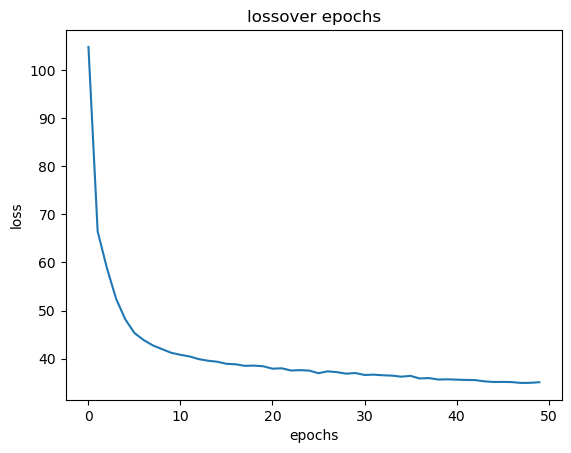

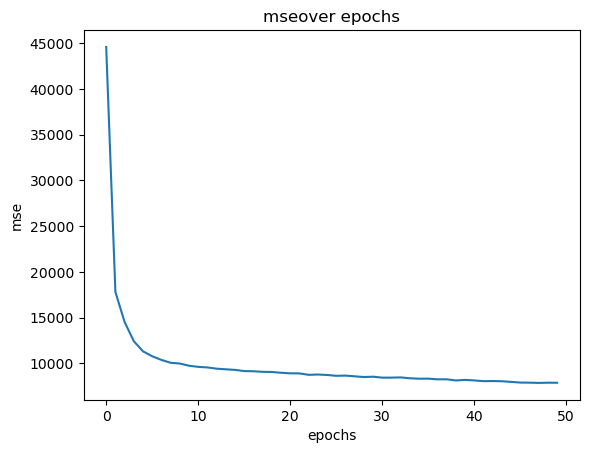

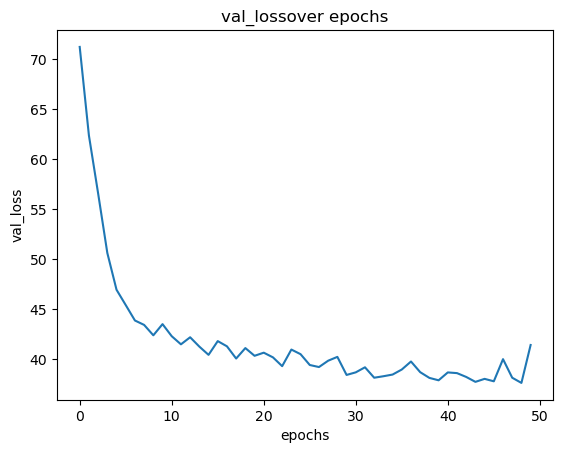

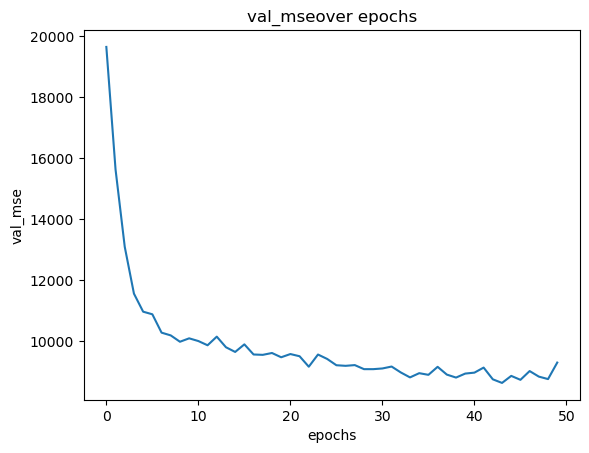

In [135]:
fit=history.history
for i in fit:
    plt.plot(fit[i])
    plt.title(i+'over epochs')
    plt.ylabel(i)
    plt.xlabel('epochs')
    plt.show()

In [137]:
y_pred=model.predict(x_test)

205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [143]:
mean_absolute_error(y_test,y_pred)

39.54901994441036